Loading dataset...
Training LightGBM with default parameters...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005604 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3303
[LightGBM] [Info] Number of data points in the train set: 44799, number of used features: 14
[LightGBM] [Info] Start training from score -1.255009
[LightGBM] [Info] Start training from score -1.626980
[LightGBM] [Info] Start training from score -1.318947
[LightGBM] [Info] Start training from score -1.382351


C:\Users\30698\miniconda3\envs\UNI\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3229
           1       1.00      1.00      1.00      2194
           2       0.53      0.49      0.51      3020
           3       0.49      0.53      0.51      2757

    accuracy                           0.75     11200
   macro avg       0.75      0.75      0.75     11200
weighted avg       0.75      0.75      0.75     11200

LightGBM Confusion Matrix:
[[3225    0    3    1]
 [   0 2193    1    0]
 [   0    0 1487 1533]
 [   1    0 1302 1454]]

Training XGBoost with default parameters...


C:\Users\30698\miniconda3\envs\UNI\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:28:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3229
           1       1.00      1.00      1.00      2194
           2       0.53      0.50      0.52      3020
           3       0.49      0.52      0.50      2757

    accuracy                           0.75     11200
   macro avg       0.76      0.76      0.76     11200
weighted avg       0.75      0.75      0.75     11200

XGBoost Confusion Matrix:
[[3228    0    1    0]
 [   0 2194    0    0]
 [   0    0 1514 1506]
 [   0    0 1323 1434]]


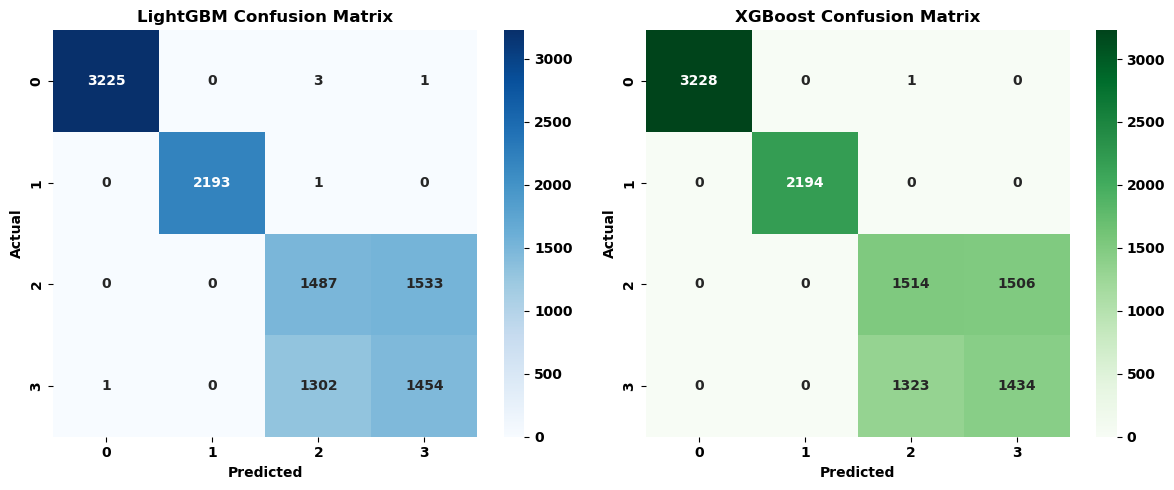

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

print("Loading dataset...")
df = pd.read_csv("Data/EngineFaultDB_Final.csv")
y = df["Fault"]
X = df.drop(columns=["Fault"])

# Outlier clipping (IQR method)
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
X_clipped = X.clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR, axis=1)

# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clipped)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("Training LightGBM with default parameters...")
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_test)
print("LightGBM Classification Report:")
print(classification_report(y_test, lgb_preds))

lgb_cm = confusion_matrix(y_test, lgb_preds)
print("LightGBM Confusion Matrix:")
print(lgb_cm)

print("\nTraining XGBoost with default parameters...")
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_preds))

xgb_cm = confusion_matrix(y_test, xgb_preds)
print("XGBoost Confusion Matrix:")
print(xgb_cm)

# Optional: plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(lgb_cm, annot=True, fmt='d', ax=axes[0], cmap="Blues")
axes[0].set_title("LightGBM Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(xgb_cm, annot=True, fmt='d', ax=axes[1], cmap="Greens")
axes[1].set_title("XGBoost Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [38]:
lgb_model.booster_.save_model("EngineAnomaly_lgbm.json")


In [39]:
xgb_model.save_model("EngineAnomaly_xgb.json")

In [40]:
import importlib
import lgb2c
importlib.reload(lgb2c)
from lgb2c import LightGBMCExporter
import lightgbm as lgb
booster = lgb.Booster(model_file="EngineAnomaly_lgbm.json")
exporter = LightGBMCExporter(booster)
result = exporter.export_header(r"2Board/LightGBM_model.h")
print(result)


Tree Stats:
  Total Trees        : 400
  Max Depth          : 19
  Min Depth          : 8
  Avg Depth          : 11.30
  Depth Std Dev      : 2.03
  Total Nodes        : 24400
  Max Nodes Per Tree : 61

Estimated Memory Usage: 311.33 KB



In [41]:
import importlib
import xgb2c
importlib.reload(xgb2c)
from xgb2c import XGBoostCExporter
import xgboost as xgb

booster = xgb.Booster()
booster.load_model("EngineAnomaly_xgb.json")
exporter = XGBoostCExporter(booster)
result = exporter.export_header(r"2Board/XGBoost_model.h")
print(result)


Tree Stats:
  Total Trees        : 400
  Max Depth          : 7
  Min Depth          : 2
  Avg Depth          : 6.14
  Depth Std Dev      : 1.46
  Total Nodes        : 21308
  Max Nodes Per Tree : 117

Estimated Memory Usage: 499.41 KB



In [42]:
def print_test_data_c_format(X_test, y_pred, var_name="test_data", pred_name="predictions"):
    """
    Print test features and predictions as clean, 100% C compatible arrays.

    Parameters:
    - X_test: 2D array-like (n_samples x n_features) of floats
    - y_pred: 1D array-like of predicted labels (ints or floats)
    - var_name: string, variable name for C features array
    - pred_name: string, variable name for C predictions array
    """
    n_samples, n_features = X_test.shape
    
    # Print sample count macro
    print(f"#define INPUTS {n_samples}")
    print(f"#define FEATURES {n_features}")
    print()
    
    # Print features array
    print(f"float {var_name}[INPUTS][FEATURES] = {{")
    for i, sample in enumerate(X_test):
        # Format each float with f suffix, fixed precision
        row_str = ", ".join(f"{float(x):.6f}f" for x in sample)
        # For last sample, no trailing comma
        comma = "," if i < n_samples - 1 else ""
        print(f"    {{ {row_str} }}{comma}")
    print("};\n")

In [43]:
print_test_data_c_format(X_test[100:140], y_test[100:140])

#define INPUTS 40
#define FEATURES 14

float test_data[INPUTS][FEATURES] = {
    { 1.807668f, 1.847246f, 1.896237f, 1.747133f, -0.604642f, 0.286425f, 1.383390f, -0.611980f, 1.185529f, 1.208525f, -0.116824f, -0.670108f, -0.784773f, -0.787681f },
    { -0.266567f, 0.030746f, -0.544684f, -0.386912f, 1.574763f, 0.526081f, -0.786645f, 1.622519f, -0.778134f, -0.427471f, 0.201947f, 0.214963f, 0.762408f, 0.755559f },
    { 1.807668f, 1.847246f, 1.896237f, 1.747133f, -0.604643f, 0.356133f, 1.373576f, -0.537588f, 1.080393f, 1.081032f, -0.081100f, -0.710338f, -1.050955f, -1.044888f },
    { -0.732430f, -0.470058f, -0.581908f, -0.668038f, 0.071952f, -0.628413f, -0.906678f, 0.042463f, -0.723871f, -0.648133f, 1.002996f, 1.220725f, 1.061863f, 1.067152f },
    { 1.807668f, 1.847246f, 1.896237f, 1.747133f, 0.553494f, 1.521572f, 1.153892f, 0.474215f, -0.616700f, 0.297531f, 1.136275f, -0.558357f, 0.279954f, 0.283069f },
    { -0.979652f, -0.675590f, -0.640711f, -0.816677f, -0.570800f, -0.614587f, -0.1906

In [44]:
import numpy as np
import pandas as pd

GREEN = '\033[92m'
RESET = '\033[0m'

# Use DataFrame slice to preserve column names
X_test_subset = X_test[100:140]
probs = lgb_model.predict_proba(X_test_subset)

# Convert to DataFrame
df = pd.DataFrame(probs, columns=["Class 0", "Class 1", "Class 2", "Class 3"])
df.index.name = "Sample"

print("Sample     Class 0   Class 1   Class 2   Class 3")
print("------------------------------------------------------------")

for i, row in df.iterrows():
    max_idx = np.argmax(row.values)
    formatted = [
        f"{GREEN}{val:.6f}{RESET}" if j == max_idx else f"{val:.6f}"
        for j, val in enumerate(row.values)
    ]
    print(f"{i:<10d} " + " ".join(formatted))


Sample     Class 0   Class 1   Class 2   Class 3
------------------------------------------------------------
0          0.999967 0.000000 0.000018 0.000015
1          0.000104 0.000082 0.462227 0.537586
2          0.999962 0.000000 0.000018 0.000020
3          0.000000 0.999909 0.000058 0.000033
4          0.999933 0.000004 0.000048 0.000015
5          0.000113 0.000088 0.414069 0.585729
6          0.999986 0.000004 0.000006 0.000004
7          0.000093 0.000071 0.473826 0.526010
8          0.000093 0.000073 0.491760 0.508074
9          0.000102 0.000082 0.505711 0.494104
10         0.000093 0.000071 0.485209 0.514626
11         0.000000 0.999906 0.000048 0.000045
12         0.000097 0.000079 0.500823 0.499001
13         0.000106 0.000083 0.516088 0.483722
14         0.000106 0.000083 0.554671 0.445141
15         0.999966 0.000000 0.000028 0.000007
16         0.999968 0.000000 0.000020 0.000012
17         0.000000 0.999828 0.000096 0.000076
18         0.000100 0.000077 0.509836 0.4899

C:\Users\30698\miniconda3\envs\UNI\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [45]:
import numpy as np
import pandas as pd

GREEN = '\033[92m'
RESET = '\033[0m'

# Use DataFrame slice to preserve column names
X_test_subset = X_test[100:140]
probs = xgb_model.predict_proba(X_test_subset)

# Convert to DataFrame
df = pd.DataFrame(probs, columns=["Class 0", "Class 1", "Class 2", "Class 3"])
df.index.name = "Sample"

print("Sample     Class 0   Class 1   Class 2   Class 3")
print("------------------------------------------------------------")

for i, row in df.iterrows():
    max_idx = np.argmax(row.values)
    formatted = [
        f"{GREEN}{val:.6f}{RESET}" if j == max_idx else f"{val:.6f}"
        for j, val in enumerate(row.values)
    ]
    print(f"{i:<10d} " + " ".join(formatted))


Sample     Class 0   Class 1   Class 2   Class 3
------------------------------------------------------------
0          0.999995 0.000000 0.000003 0.000002
1          0.000032 0.000025 0.418825 0.581118
2          0.999989 0.000000 0.000008 0.000003
3          0.000000 0.999949 0.000043 0.000008
4          0.999965 0.000013 0.000019 0.000003
5          0.000043 0.000149 0.507860 0.491949
6          0.999940 0.000032 0.000021 0.000007
7          0.000047 0.000032 0.596733 0.403188
8          0.000039 0.000031 0.625800 0.374130
9          0.000013 0.000046 0.396360 0.603581
10         0.000086 0.000029 0.506868 0.493016
11         0.000000 0.999942 0.000041 0.000017
12         0.000025 0.000019 0.506985 0.492971
13         0.000020 0.000016 0.482681 0.517284
14         0.000010 0.000011 0.557154 0.442825
15         0.999989 0.000000 0.000008 0.000003
16         0.999972 0.000002 0.000018 0.000008
17         0.000002 0.999341 0.000509 0.000147
18         0.000013 0.000029 0.532172 0.4677